In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np

# Load calibration data for head pose x and y angle limits (for State 2)
calibration_file = 'user_a01173858_I_L_calibration.json'
with open(calibration_file, 'r') as file:
    calibration_data = json.load(file)

# Load validation data
validation_file = 'user_a01173858_I_L_facial_feature_data.csv'
validation_df = pd.read_csv(validation_file)



In [19]:
# Preprocess data by removing instances where the user was not detected.
validation_df = validation_df[validation_df['Face Detected'] != 0]

# Modify timestamp to express elapsed time
timestamp_start = validation_df['Timestamp'].iloc[0]
validation_df['Elapsed Time'] = validation_df['Timestamp'] - timestamp_start

validation_df

,Timestamp,Face Detected,EAR Left,EAR Right,EAR Avg,Blink Rate,MAR,Head Rot X,Head Rot Y,Head Rot Z,State,Elapsed Time
0,1.727218e+09,1,0.348508,0.278543,0.313526,0.0,0.011628,8.430674,-38.597407,-0.079988,0,0.000000
1,1.727218e+09,1,0.316228,0.310504,0.313366,0.0,0.000000,8.670031,-38.760299,-0.068026,0,0.034263
2,1.727218e+09,1,0.332871,0.305502,0.319187,0.0,0.000000,8.537036,-38.570936,-0.073891,0,0.076603
3,1.727218e+09,1,0.339692,0.278543,0.309118,0.0,0.000000,8.076393,-37.082702,-0.071030,0,0.150638
4,1.727218e+09,1,0.339692,0.303798,0.321745,0.0,0.000000,8.790506,-37.231928,-0.071920,0,0.208441
...,...,...,...,...,...,...,...,...,...,...,...,...
2327,1.727219e+09,1,0.320092,0.274265,0.297179,0.0,0.000000,11.238704,-29.147895,-0.074186,0,140.066648
2328,1.727219e+09,1,0.324824,0.263781,0.294302,0.0,0.011337,12.373783,-28.614524,-0.076726,0,140.110904
2329,1.727219e+09,1,0.298642,0.241466,0.270054,0.0,0.000000,12.711155,-28.628239,-0.069212,0,140.172364
2330,1.727219e+09,1,0.275354,0.266274,0.270814,0.0,0.000000,12.874253,-29.263718,-0.065872,0,140.247023


In [20]:
# Add vertical lines for commanded state transitions
commanded_state_transitions = [0, 25, 41, 48, 70, 83, 98, 112, 127]
###### Generic ------ commanded_state_transitions = [0, 25, 40, 50, 65, 75, 90, 100, 115]
commanded_state_transitions.append(validation_df['Elapsed Time'].iloc[-1])

# Add a new commanded state column based on commanded_state_transitions
state_labels = ['State 0', 'State 1', 'State 0', 'State 2', 'State 0', 'State 3', 'State 0', 'State 4', 'State 0']
state_mapping = {
    'State 0': 0,
    'State 1': 1,
    'State 2': 2,
    'State 3': 3,
    'State 4': 4
}
validation_df['Commanded State'] = 'Unknown'
for i in range(len(commanded_state_transitions) - 1):
    start = commanded_state_transitions[i]
    end = commanded_state_transitions[i + 1]
    mask = (validation_df['Elapsed Time'] >= start) & (validation_df['Elapsed Time'] <= end)
    validation_df.loc[mask, 'Commanded State'] = state_labels[i]

# Map the state labels to numerical values
validation_df['Commanded State'] = validation_df['Commanded State'].map(state_mapping)
validation_df

,Timestamp,Face Detected,EAR Left,EAR Right,EAR Avg,Blink Rate,MAR,Head Rot X,Head Rot Y,Head Rot Z,State,Elapsed Time,Commanded State
0,1.727218e+09,1,0.348508,0.278543,0.313526,0.0,0.011628,8.430674,-38.597407,-0.079988,0,0.000000,0
1,1.727218e+09,1,0.316228,0.310504,0.313366,0.0,0.000000,8.670031,-38.760299,-0.068026,0,0.034263,0
2,1.727218e+09,1,0.332871,0.305502,0.319187,0.0,0.000000,8.537036,-38.570936,-0.073891,0,0.076603,0
3,1.727218e+09,1,0.339692,0.278543,0.309118,0.0,0.000000,8.076393,-37.082702,-0.071030,0,0.150638,0
4,1.727218e+09,1,0.339692,0.303798,0.321745,0.0,0.000000,8.790506,-37.231928,-0.071920,0,0.208441,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2327,1.727219e+09,1,0.320092,0.274265,0.297179,0.0,0.000000,11.238704,-29.147895,-0.074186,0,140.066648,0
2328,1.727219e+09,1,0.324824,0.263781,0.294302,0.0,0.011337,12.373783,-28.614524,-0.076726,0,140.110904,0
2329,1.727219e+09,1,0.298642,0.241466,0.270054,0.0,0.000000,12.711155,-28.628239,-0.069212,0,140.172364,0
2330,1.727219e+09,1,0.275354,0.266274,0.270814,0.0,0.000000,12.874253,-29.263718,-0.065872,0,140.247023,0


In [21]:
# Calculate blink rate for each commanded state period
# Set EAR threshold for blink detection (60% of the calibrated ear_avg value)
ear_threshold = calibration_data['ear_avg'] * 0.6

# Add a new column to mark blinks (1 if blink, 0 otherwise)
validation_df['Blink'] = np.where(validation_df['EAR Avg'] < ear_threshold, 1, 0)

# Calculate blink rate for each commanded state period
blink_rates = []
for i in range(len(commanded_state_transitions) - 1):
    start = commanded_state_transitions[i]
    end = commanded_state_transitions[i + 1]
    
    # Filter data within the current commanded state period
    period_df = validation_df[(validation_df['Elapsed Time'] >= start) & (validation_df['Elapsed Time'] < end)]
    
    # Count blinks (blink starts)
    blink_count = 0
    in_blink = False
    
    for blink in period_df['Blink']:
        if blink == 1 and not in_blink:
            blink_count += 1
            in_blink = True
        elif blink == 0:
            in_blink = False
    
    # Calculate blink rate (blinks per minute)
    period_duration = end - start
    blink_rate = blink_count / period_duration*60 if period_duration > 0 else 0
    blink_rates.append({'Start Time': start, 'End Time': end, 'Blink Rate': blink_rate})
    
    # Assign blink rate to the corresponding rows in validation_df
    validation_df.loc[(validation_df['Elapsed Time'] >= start) & (validation_df['Elapsed Time'] <= end), 'Blink Rate'] = blink_rate
    
validation_df
validation_df.to_csv('validation_df.csv', index=False)

In [22]:
ear_threshold = calibration_data['ear_avg'] * 0.6

# 1. Identify raw frame-by-frame blinks based on EAR threshold
validation_df['Blink'] = np.where(validation_df['EAR Avg'] < ear_threshold, 1, 0)

# Detect blink onsets
validation_df['Blink Onset'] = ((validation_df['Blink'] == 1) & (validation_df['Blink'].shift(1, fill_value=0) == 0)).astype(int)

# Sampling rate estimate
fs = 1 / np.median(np.diff(validation_df['Elapsed Time']))

window_sec = 10; window_samples = int(window_sec * fs)
validation_df['Blink Rate'] = validation_df['Blink Onset'].rolling(window=window_samples,center=True,min_periods=1).sum()*(60/window_sec)

# validation_df = df_timed.reset_index(drop=True)
validation_df.to_csv('validation_df2.csv', index=False)

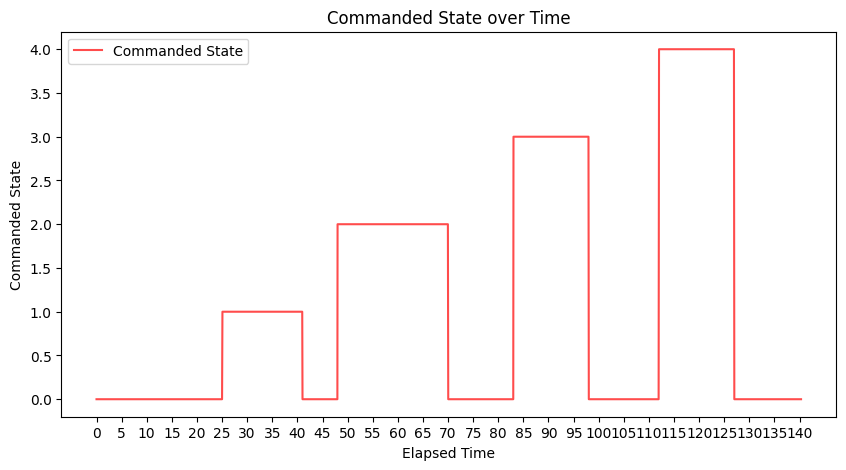

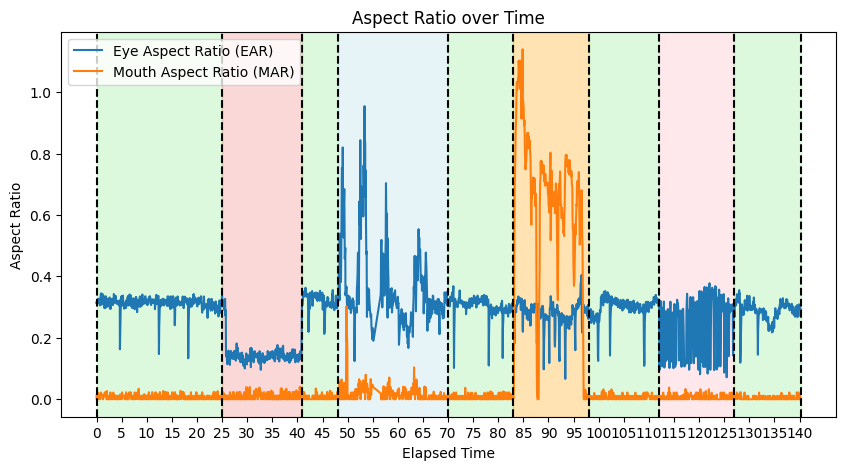

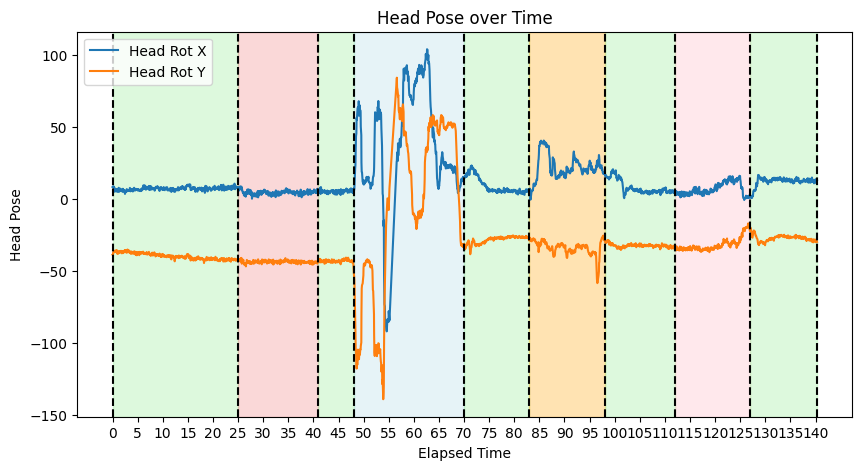

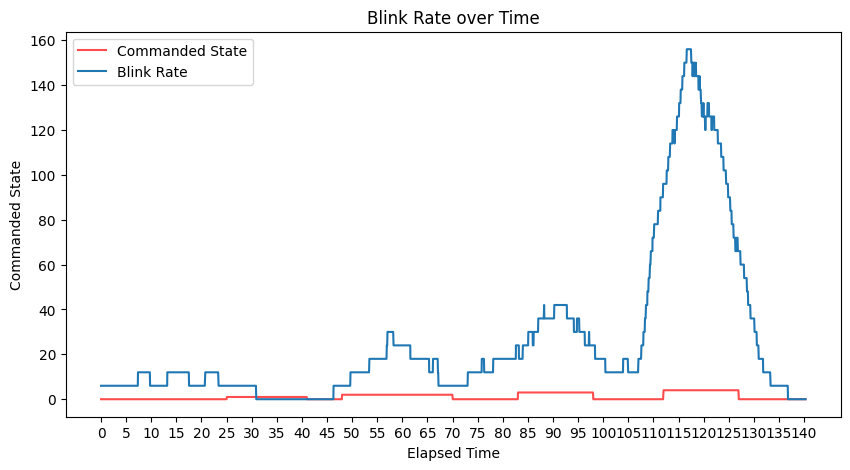

In [23]:
# Time-Series Plot for Commanded State
plt.figure(figsize=(10, 5))
plt.plot(validation_df['Elapsed Time'], validation_df['Commanded State'], label='Commanded State', color='red', linestyle='-', alpha=0.7)
plt.xlabel('Elapsed Time')
plt.ylabel('Commanded State')
plt.title('Commanded State over Time')
plt.legend()
plt.xticks(ticks=range(0, int(validation_df['Elapsed Time'].max()) + 5, 5))
plt.show()

# Time-Series Plot for Aspect Ratios
plt.figure(figsize=(10, 5))
plt.plot(validation_df['Elapsed Time'], validation_df['EAR Avg'], label='Eye Aspect Ratio (EAR)')
plt.plot(validation_df['Elapsed Time'], validation_df['MAR'], label='Mouth Aspect Ratio (MAR)')
plt.xlabel('Elapsed Time')
plt.ylabel('Aspect Ratio')
plt.title('Aspect Ratio over Time')
plt.legend()
for transition in commanded_state_transitions:
    plt.axvline(x=transition, color='black', linestyle='--', label='State Transition')
plt.xticks(ticks=range(0, int(validation_df['Elapsed Time'].max()) + 5, 5))

# Highlight commanded states with shaded regions
state_labels = ['State 0', 'State 1', 'State 0', 'State 2', 'State 0', 'State 3', 'State 0', 'State 4', 'State 0']
state_colors = ['lightgreen', 'lightcoral', 'lightgreen', 'lightblue', 'lightgreen', 'orange', 'lightgreen', 'lightpink', 'lightgreen']

for i in range(len(commanded_state_transitions) - 1):
    start = commanded_state_transitions[i]
    end = commanded_state_transitions[i + 1]
    state = state_labels[i]
    color = state_colors[i]
    plt.axvspan(start, end, color=color, alpha=0.3, label=state)
plt.show()


# Time-Series Plot for Head Pose
plt.figure(figsize=(10, 5))
plt.plot(validation_df['Elapsed Time'], validation_df['Head Rot X'], label='Head Rot X')
plt.plot(validation_df['Elapsed Time'], validation_df['Head Rot Y'], label='Head Rot Y')
plt.xlabel('Elapsed Time')
plt.ylabel('Head Pose')
plt.title('Head Pose over Time')
plt.legend()
for transition in commanded_state_transitions:
    plt.axvline(x=transition, color='black', linestyle='--', label='State Transition')

plt.xticks(ticks=range(0, int(validation_df['Elapsed Time'].max()) + 5, 5))
for i in range(len(commanded_state_transitions) - 1):
    start = commanded_state_transitions[i]
    end = commanded_state_transitions[i + 1]
    state = state_labels[i]
    color = state_colors[i]
    plt.axvspan(start, end, color=color, alpha=0.3, label=state)
plt.show()

# Time-Series Plot for Blink Rate per Commanded State
plt.figure(figsize=(10, 5))
plt.plot(validation_df['Elapsed Time'], validation_df['Commanded State'], label='Commanded State', color='red', linestyle='-', alpha=0.7)
plt.plot(validation_df['Elapsed Time'], validation_df['Blink Rate'], label='Blink Rate')
plt.xlabel('Elapsed Time')
plt.ylabel('Commanded State')
plt.title('Blink Rate over Time')
plt.legend()
plt.xticks(ticks=range(0, int(validation_df['Elapsed Time'].max()) + 5, 5))
plt.show()

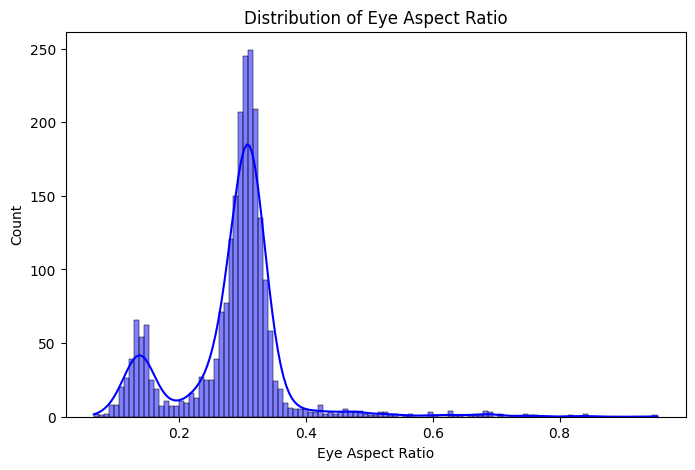

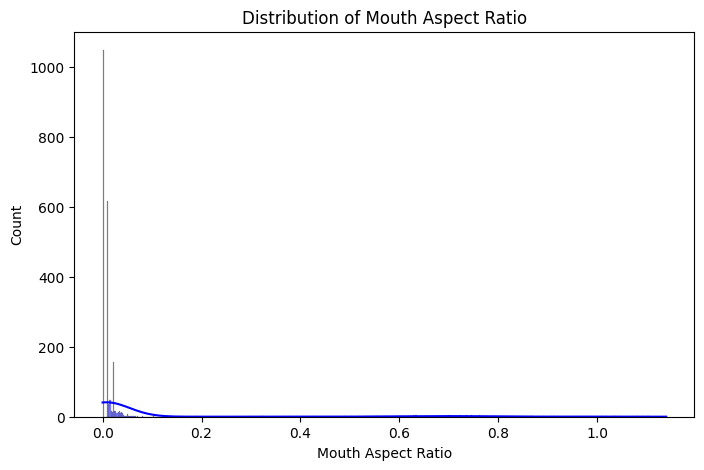

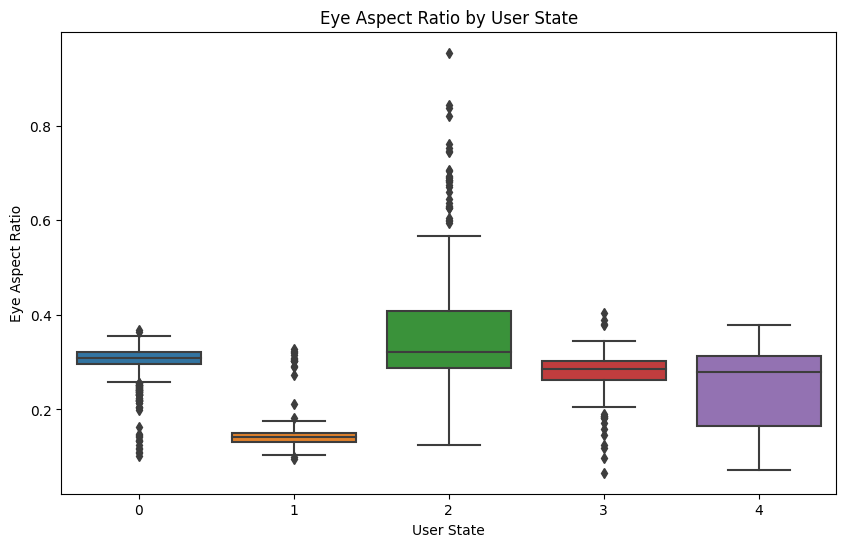

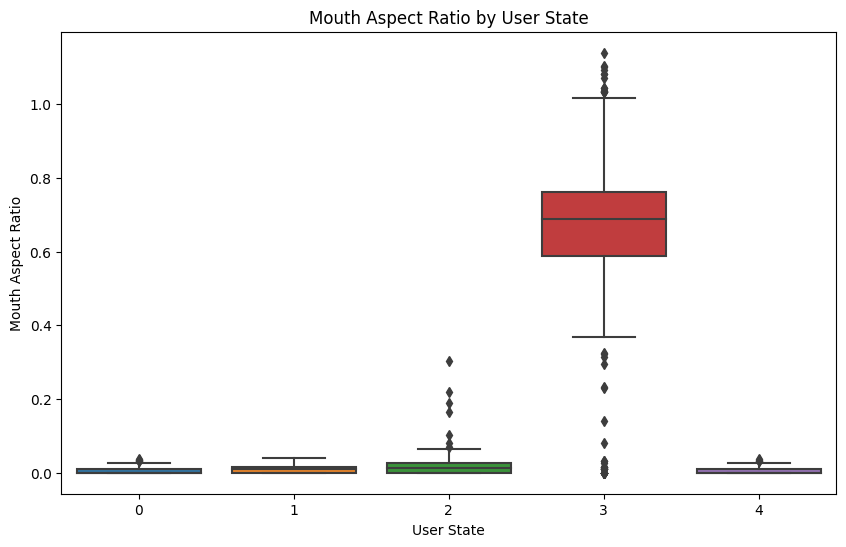

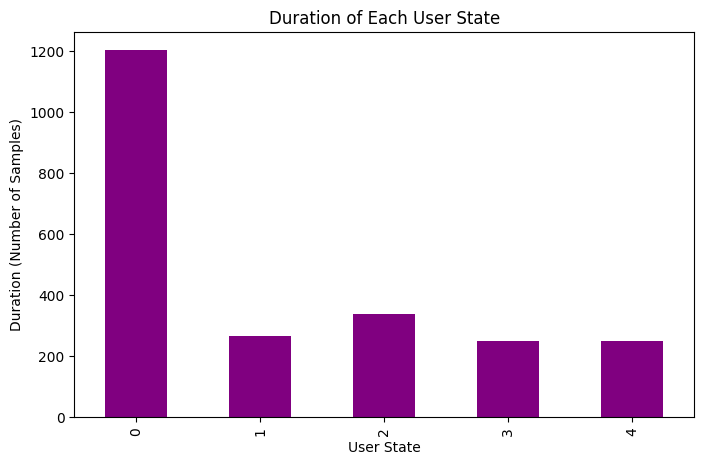

In [24]:
# Histogram for Distribution of EAR
plt.figure(figsize=(8, 5))
sns.histplot(validation_df['EAR Avg'], kde=True, color='blue')
plt.xlabel('Eye Aspect Ratio')
plt.title('Distribution of Eye Aspect Ratio')
plt.show()

# Histogram for Distribution of MAR
plt.figure(figsize=(8, 5))
sns.histplot(validation_df['MAR'], kde=True, color='blue')
plt.xlabel('Mouth Aspect Ratio')
plt.title('Distribution of Mouth Aspect Ratio')
plt.show()

# Box Plot for EAR by User State
plt.figure(figsize=(10, 6))
sns.boxplot(x='Commanded State', y='EAR Avg', data=validation_df)
plt.xlabel('User State')
plt.ylabel('Eye Aspect Ratio')
plt.title('Eye Aspect Ratio by User State')
plt.show()

# Box Plot for EAR by User State
plt.figure(figsize=(10, 6))
sns.boxplot(x='Commanded State', y='MAR', data=validation_df)
plt.xlabel('User State')
plt.ylabel('Mouth Aspect Ratio')
plt.title('Mouth Aspect Ratio by User State')
plt.show()

# Correlation Heatmap for Features
#plt.figure(figsize=(10, 8))
#corr_matrix = validation_df.corr()
#sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
#plt.title('Correlation Matrix of Features')
#plt.show()

# Pair Plot to Visualize Relationships between Features
#sns.pairplot(validation_df[['EAR Avg', 'MAR', 'Head Rot X', 'Head Rot Y', 'State']])
#plt.show()

# Bar Chart for State Duration
state_durations = validation_df.groupby('Commanded State')['Elapsed Time'].count()
plt.figure(figsize=(8, 5))
state_durations.plot(kind='bar', color='purple')
plt.xlabel('User State')
plt.ylabel('Duration (Number of Samples)')
plt.title('Duration of Each User State')
plt.show()

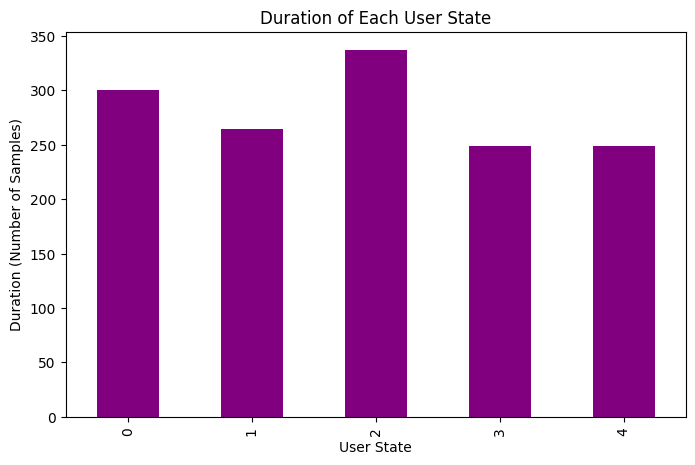

In [25]:
# Undersample State 0 (Neutral) to balance the dataset
from sklearn.utils import resample

# Separate majority and minority classes
state_0_df = validation_df[validation_df['Commanded State'] == 0]
other_states_df = validation_df[validation_df['Commanded State'] != 0]

# Downsample State 0 to match the size of other states (around 300 instances)
state_0_downsampled = resample(state_0_df, 
                                replace=False,  # Sample without replacement
                                n_samples=300,  # Match to minority class size
                                random_state=42)  # For reproducibility

# Combine downsampled State 0 with other states
validation_df = pd.concat([state_0_downsampled, other_states_df])

# Shuffle the resulting DataFrame
validation_df = validation_df.sample(frac=1, random_state=42).reset_index(drop=True)
#sns.pairplot(validation_df[['EAR Avg', 'MAR', 'Head Rot X', 'Head Rot Y', 'Commanded State']])
#plt.show()

# Bar Chart for State Duration
state_durations = validation_df.groupby('Commanded State')['Elapsed Time'].count()
plt.figure(figsize=(8, 5))
state_durations.plot(kind='bar', color='purple')
plt.xlabel('User State')
plt.ylabel('Duration (Number of Samples)')
plt.title('Duration of Each User State')
plt.show()

In [ ]:
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score, auc, f1_score
from sklearn.ensemble import RandomForestClassifier

# Select features
features = validation_df[['EAR Avg', 'MAR', 'Head Rot X', 'Head Rot Y', 'Blink Rate']]
labels = validation_df['Commanded State']

# Standardize features
scaler = StandardScaler(); scaler.fit(features)
scaled_features = scaler.transform(features)

# Split data into training and testing sets (70% training, 30% testing)
# X_train, X_test, y_train, y_test = train_test_split(scaled_features, labels, test_size=0.3, random_state=123)

# ML models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=None)
svm_model = LinearSVC(C=1, random_state=42)

# heuristic-based prediction for real-time
y_predH = validation_df['State']

# Lets do k-fold cross validation instead with shuffled labels
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
accs = []; cfms_svm = []; roc_data = pd.DataFrame()
acc_data = pd.DataFrame()

for fold, (train_idx, test_idx) in enumerate(skf.split(scaled_features, labels)):
    X_train, X_test = scaled_features[train_idx], scaled_features[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]

    # Train SVM with linear kernel
    svm_model.fit(X_train, y_train)
    rf_model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = svm_model.predict(X_test)
    y_predh = y_predH[test_idx]
    y_score = svm_model.decision_function(X_test)

    y_test_bin = label_binarize(y_test, classes=np.unique(labels))
    acc = []
    fold_data = pd.DataFrame()
    for i in range(len(np.unique(labels))):

        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        temp_data = pd.DataFrame({'fold': fold,'class': i, 'fpr': fpr, 'tpr': tpr})
        fold_data = pd.concat([fold_data, temp_data], axis=0)
        
        auc = np.trapz(tpr, fpr); acc.append(auc)
    roc_data = pd.concat([roc_data,fold_data], axis=0)
    accs.append(np.mean(acc))
    cfms.append(confusion_matrix(y_test,y_pred))

    temp_data = pd.DataFrame({'fold': fold, 'accH': accuracy_score(y_test,y_predh), 'f1H': f1_score(y_test,y_predh, average='macro'), 'accM': accuracy_score(y_test,y_pred), 'f1M': f1_score(y_test,y_pred, average='macro')}, index=[fold])
    acc_data = pd.concat([acc_data, temp_data],axis=0)

    # auc = roc_auc_score(y_test, y_score)
    # print(print(y_score.shape))
    # auc = roc_auc_score(y_test, y_score, multi_class='ovr', average='macro') # weighted

    # fpr, tpr, thresholds = roc_curve(y_test, y_score)
    # auc = roc_auc_score(y_test, y_score)

    # roc_data.append({'fold': fold, 'fpr': fpr, 'tpr': tpr, 'thresholds': thresholds, 'auc': auc})
    # accs.append(accuracy_score(y_test, y_pred))
    accs.append(auc)
print(accs)
perm_acc = np.mean(accs)

# Evaluate the model
print("Accuracy:", perm_acc)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# we can do AUC-ROC curve for each k-fold given k = 5 to show consistency
pd.DataFrame(roc_data).to_csv('skfold_res10.csv',index=False)
acc_data.to_csv('skfold_acccomp10.csv',index=False)

[0.9555789923889947, 1.0, 0.9346739897386687, 0.9986086956521739, 0.978214471819791, 0.9986086956521739, 0.9419474710145905, 1.0, 0.94207945322062, 0.9989565217391305, 0.9415561530491171, 0.9989565217391304, 0.9516307273867859, 0.999304347826087, 0.9569877778188219, 0.9996521739130435, 0.9550346625001463, 0.9982608695652174, 0.9725141393619248, 1.0]
Accuracy: 0.9761282832193208
Confusion Matrix:
 [[24  1  5  0  0]
 [ 0 27  0  0  0]
 [ 5  0 28  0  0]
 [ 0  0  2 23  0]
 [ 0  0  0  0 25]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.80      0.81        30
           1       0.96      1.00      0.98        27
           2       0.80      0.85      0.82        33
           3       1.00      0.92      0.96        25
           4       1.00      1.00      1.00        25

    accuracy                           0.91       140
   macro avg       0.92      0.91      0.92       140
weighted avg       0.91      0.91      0.91       1

In [ ]:
# print(calibration_data)
# print(validation_df)
def th_model(x,calib):
    
    # 'EAR Avg', 'MAR', 'Head Rot X', 'Head Rot Y', 'Blink Rate'
    y_pred = []
    for xi in x:
        # yawning?
        if xi[1] > 1.3*calib['mar']:
            state = 3
        # out of safe zone?
        elif (xi[2] > calib['head_rotations']['down_right'][1] and xi[2] < calib['head_rotations']['up_left'][1]) and \
             (xi[3] > calib['head_rotations']['up_left'][2] and xi[3] < calib['head_rotations']['down_right'][2]):
            state = 2

        # fast Blinking?
        elif xi[4] > 30:
            state = 4

        # closed eyes?
        elif xi[0] < 0.5*calib['ear_avg']:
            state = 1

        # neutral?
        else:
            state = 0
        y_pred.append(state)
    return y_pred
NEUTRAL, CLOSED_EYES, HEAD_TURN, YAWN, FAST_BLINK = range(5)
def th_model_voting(x, calib):
    x = np.asarray(x, dtype=float)
    ear, mar, head_x, head_y, blink_rate = x[:, 0], x[:, 1], x[:, 2], x[:, 3], x[:, 4]

    rot = calib['head_rotations']
    x_min, x_max = rot['up_left'][0], rot['down_right'][0]   # fixed: min/max consistent with y
    y_min, y_max = rot['up_left'][1], rot['down_right'][1]

    n = len(x)
    scores = np.zeros((n, 5))
    scores[:, NEUTRAL]      = 0.1
    scores[:, YAWN]        += 1.5 * (mar > 1.3 * calib['mar'])
    scores[:, HEAD_TURN]   += 1.2 * ((head_x < x_min) | (head_x > x_max) |
                                      (head_y < y_min) | (head_y > y_max))
    scores[:, FAST_BLINK]  += 1.1 * (blink_rate > 30)
    scores[:, CLOSED_EYES] += 1.4 * (ear < 0.5 * calib['ear_avg'])

    return np.argmax(scores, axis=1).tolist()

cms = np.array(cfms)  # shape: (10, 5, 5)

# Pooled OOF confusion matrix (this is your primary "training" CM)
pooled_cm = cms.sum(axis=0)

# Variability across folds (supplementary) — normalize each fold to row-%, then mean/std
cms_norm = cms / cms.sum(axis=2, keepdims=True)  # row-normalize each fold's CM
mean_cm = cms_norm.mean(axis=0); std_cm  = cms_norm.std(axis=0)

print(pooled_cm / pooled_cm.sum(axis=1, keepdims=True) )
print(mean_cm)

# train the model for testing cf
svm_model.fit(scaled_features, labels)




[[0.84       0.01666667 0.08333333 0.         0.06      ]
 [0.05283019 0.94716981 0.         0.         0.        ]
 [0.19881306 0.0148368  0.77448071 0.01186944 0.        ]
 [0.01606426 0.         0.08433735 0.89959839 0.        ]
 [0.         0.         0.         0.         1.        ]]
[[0.84       0.01666667 0.08333333 0.         0.06      ]
 [0.05299145 0.94700855 0.         0.         0.        ]
 [0.19848485 0.01479501 0.77486631 0.01185383 0.        ]
 [0.01616667 0.         0.08433333 0.8995     0.        ]
 [0.         0.         0.         0.         1.        ]]


LinearSVC(C=1, random_state=42)

In [10]:
# Define parameter grid for SVM
param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'gamma': [0.1, 1, 10]}

# Apply GridSearchCV
grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get the best parameters and best accuracy
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)


Best Parameters: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
Best Accuracy: 0.9722222222222221


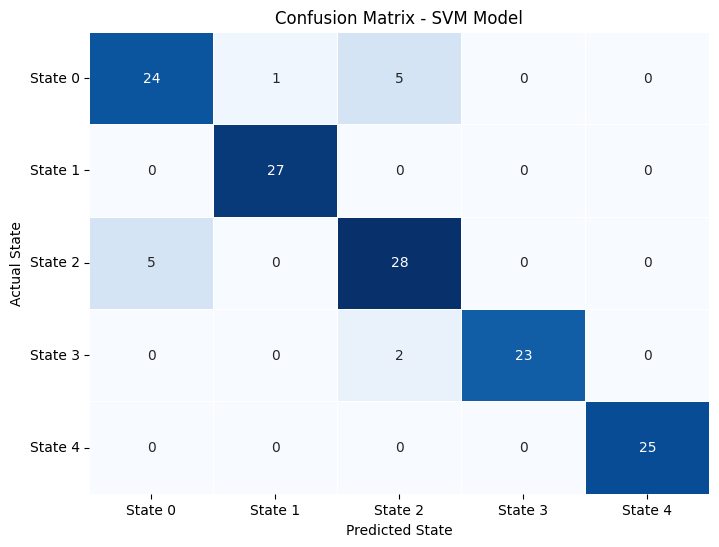

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a heatmap to visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g', cbar=False, linewidths=0.5)

# Add labels and title
plt.xlabel('Predicted State')
plt.ylabel('Actual State')
plt.title('Confusion Matrix - SVM Model')
plt.xticks(ticks=np.arange(5) + 0.5, labels=['State 0', 'State 1', 'State 2', 'State 3', 'State 4'])
plt.yticks(ticks=np.arange(5) + 0.5, labels=['State 0', 'State 1', 'State 2', 'State 3', 'State 4'], rotation=0)
plt.show()


In [12]:
# Load the new validation dataset
new_validation_file = 'user_a01173858_I_SL_facial_feature_data.csv'
new_validation_df = pd.read_csv(new_validation_file)

# Preprocess new validation data
# Remove instances where the user was not detected
new_validation_df = new_validation_df[new_validation_df['Face Detected'] != 0]

# Modify timestamp to express elapsed time
timestamp_start = new_validation_df['Timestamp'].iloc[0]
new_validation_df['Elapsed Time'] = new_validation_df['Timestamp'] - timestamp_start

# Define commanded states for the new validation data
commanded_state_transitions = [0, 25, 40, 51, 67, 78, 88, 105, 123]
commanded_state_transitions.append(new_validation_df['Elapsed Time'].iloc[-1])
state_labels = ['State 0', 'State 1', 'State 0', 'State 2', 'State 0', 'State 3', 'State 0', 'State 4', 'State 0']

# Add a new commanded state column based on commanded_state_transitions
new_validation_df['Commanded State'] = 'Unknown'
for i in range(len(commanded_state_transitions) - 1):
    start = commanded_state_transitions[i]
    end = commanded_state_transitions[i + 1]
    mask = (new_validation_df['Elapsed Time'] >= start) & (new_validation_df['Elapsed Time'] <= end)
    new_validation_df.loc[mask, 'Commanded State'] = state_labels[i]

# Map the state labels to numerical values
state_mapping = {
    'State 0': 0,
    'State 1': 1,
    'State 2': 2,
    'State 3': 3,
    'State 4': 4
}
new_validation_df['Commanded State'] = new_validation_df['Commanded State'].map(state_mapping)

# Set EAR threshold for blink detection (50% of the calibrated ear_avg value)
calibration_file = 'user_a01173858_I_L_calibration.json'
with open(calibration_file, 'r') as file:
    calibration_data = json.load(file)
ear_threshold = calibration_data['ear_avg'] * 0.6

# 1. Identify raw frame-by-frame blinks based on EAR threshold
new_validation_df['Blink'] = np.where(new_validation_df['EAR Avg'] < ear_threshold, 1, 0)

# Detect blink onsets
new_validation_df['Blink Onset'] = ((new_validation_df['Blink'] == 1) & (new_validation_df['Blink'].shift(1, fill_value=0) == 0)).astype(int)

# Sampling rate estimate
fs = 1 / np.median(np.diff(new_validation_df['Elapsed Time']))

window_sec = 30; window_samples = int(window_sec * fs)
new_validation_df['Blink Rate'] = new_validation_df['Blink Onset'].rolling(window=window_samples,center=True,min_periods=1).sum()*(60/window_sec)

# validation_df = df_timed.reset_index(drop=True)
new_validation_df.to_csv('new_validation_df2.csv', index=False)


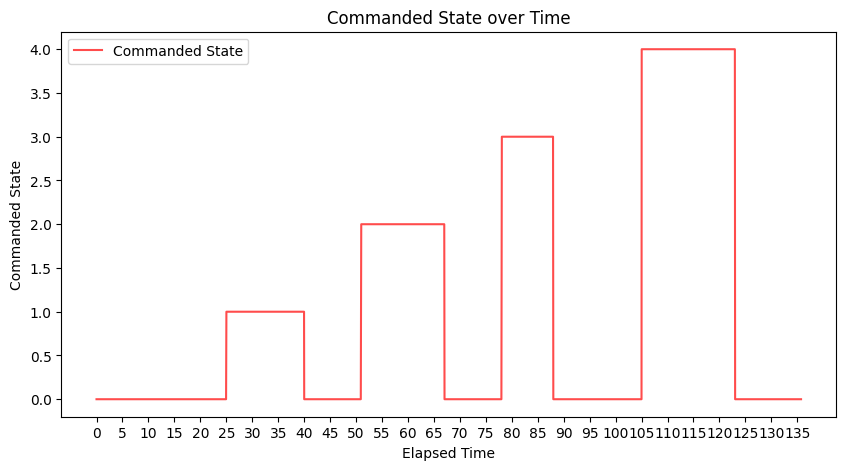

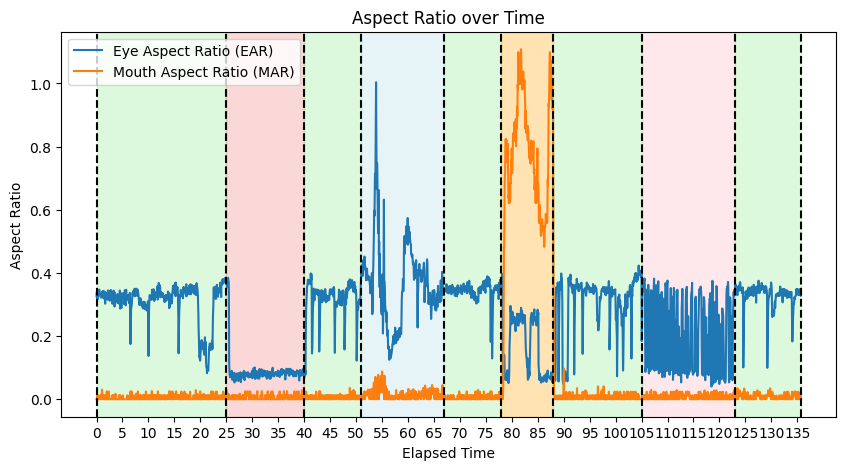

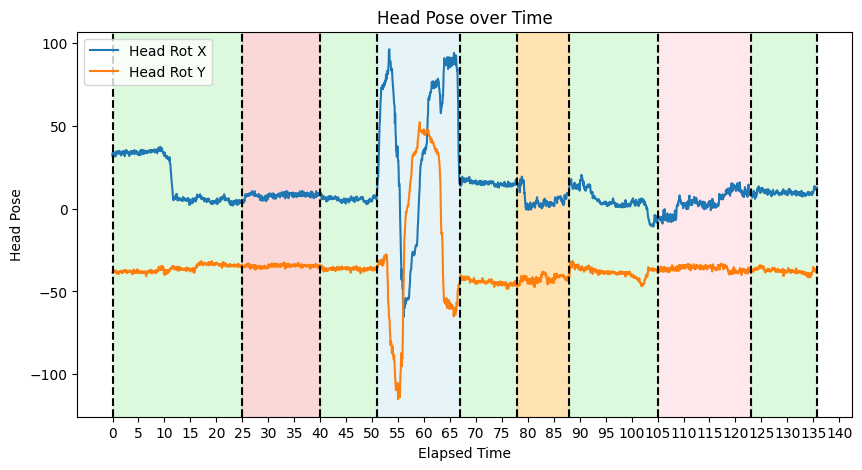

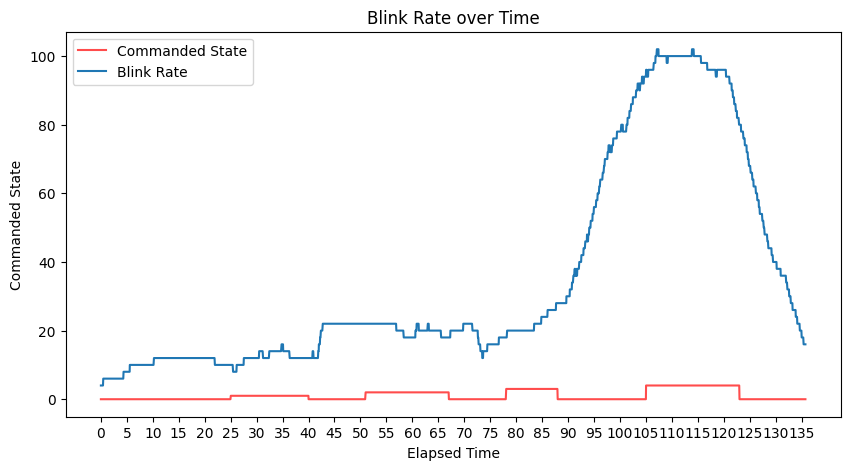

In [13]:
# Time-Series Plot for Commanded State
plt.figure(figsize=(10, 5))
plt.plot(new_validation_df['Elapsed Time'], new_validation_df['Commanded State'], label='Commanded State', color='red', linestyle='-', alpha=0.7)
plt.xlabel('Elapsed Time')
plt.ylabel('Commanded State')
plt.title('Commanded State over Time')
plt.legend()
plt.xticks(ticks=range(0, int(new_validation_df['Elapsed Time'].max()) + 5, 5))
plt.show()

# Time-Series Plot for Aspect Ratios
plt.figure(figsize=(10, 5))
plt.plot(new_validation_df['Elapsed Time'], new_validation_df['EAR Avg'], label='Eye Aspect Ratio (EAR)')
plt.plot(new_validation_df['Elapsed Time'], new_validation_df['MAR'], label='Mouth Aspect Ratio (MAR)')
plt.xlabel('Elapsed Time')
plt.ylabel('Aspect Ratio')
plt.title('Aspect Ratio over Time')
plt.legend()
for transition in commanded_state_transitions:
    plt.axvline(x=transition, color='black', linestyle='--', label='State Transition')
plt.xticks(ticks=range(0, int(new_validation_df['Elapsed Time'].max()) + 5, 5))

# Highlight commanded states with shaded regions
state_labels = ['State 0', 'State 1', 'State 0', 'State 2', 'State 0', 'State 3', 'State 0', 'State 4', 'State 0']
state_colors = ['lightgreen', 'lightcoral', 'lightgreen', 'lightblue', 'lightgreen', 'orange', 'lightgreen', 'lightpink', 'lightgreen']

for i in range(len(commanded_state_transitions) - 1):
    start = commanded_state_transitions[i]
    end = commanded_state_transitions[i + 1]
    state = state_labels[i]
    color = state_colors[i]
    plt.axvspan(start, end, color=color, alpha=0.3, label=state)
plt.show()


# Time-Series Plot for Head Pose
plt.figure(figsize=(10, 5))
plt.plot(new_validation_df['Elapsed Time'], new_validation_df['Head Rot X'], label='Head Rot X')
plt.plot(new_validation_df['Elapsed Time'], new_validation_df['Head Rot Y'], label='Head Rot Y')
plt.xlabel('Elapsed Time')
plt.ylabel('Head Pose')
plt.title('Head Pose over Time')
plt.legend()
for transition in commanded_state_transitions:
    plt.axvline(x=transition, color='black', linestyle='--', label='State Transition')

plt.xticks(ticks=range(0, int(validation_df['Elapsed Time'].max()) + 5, 5))
for i in range(len(commanded_state_transitions) - 1):
    start = commanded_state_transitions[i]
    end = commanded_state_transitions[i + 1]
    state = state_labels[i]
    color = state_colors[i]
    plt.axvspan(start, end, color=color, alpha=0.3, label=state)
plt.show()


# Time-Series Plot for Blink Rate per Commanded State
plt.figure(figsize=(10, 5))
plt.plot(new_validation_df['Elapsed Time'], new_validation_df['Commanded State'], label='Commanded State', color='red', linestyle='-', alpha=0.7)
plt.plot(new_validation_df['Elapsed Time'], new_validation_df['Blink Rate'], label='Blink Rate')
plt.xlabel('Elapsed Time')
plt.ylabel('Commanded State')
plt.title('Blink Rate over Time')
plt.legend()
plt.xticks(ticks=range(0, int(new_validation_df['Elapsed Time'].max()) + 5, 5))
plt.show()

[[0.62695925 0.07366771 0.18338558 0.0015674  0.11442006]
 [0.03212851 0.96385542 0.00401606 0.         0.        ]
 [0.23595506 0.00749064 0.74157303 0.01498127 0.        ]
 [0.02424242 0.01818182 0.         0.95757576 0.        ]
 [0.         0.         0.         0.         1.        ]]
Confusion Matrix on New Validation Data:
 [[800  94 234   2 146]
 [  8 240   1   0   0]
 [ 63   2 198   4   0]
 [  4   3   0 158   0]
 [  0   0   0   0 299]]
Classification Report on New Validation Data:
               precision    recall  f1-score   support

           0       0.91      0.63      0.74      1276
           1       0.71      0.96      0.82       249
           2       0.46      0.74      0.57       267
           3       0.96      0.96      0.96       165
           4       0.67      1.00      0.80       299

    accuracy                           0.75      2256
   macro avg       0.74      0.86      0.78      2256
weighted avg       0.81      0.75      0.75      2256

Accuracy on New

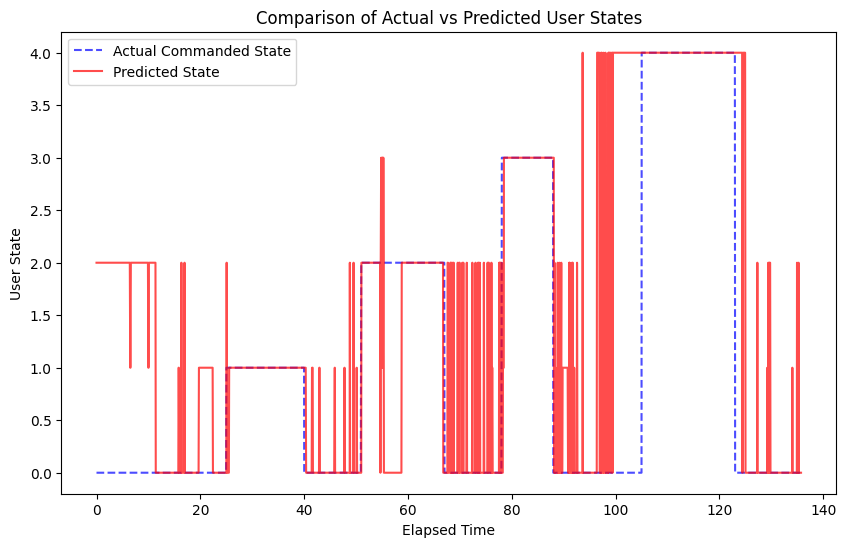

In [ ]:
# Standardize the features using the scaler fitted during training
features_new = new_validation_df[['EAR Avg', 'MAR', 'Head Rot X', 'Head Rot Y', 'Blink Rate']]
scaled_features_new = scaler.transform(features_new)  # Replace fit_transform with transform if scaler is already fitted

# Make predictions using the trained SVM model
# svm_model = SVC(kernel='linear', C=1.0, random_state=42)  # Assuming the model is already trained
# predictions = svm_model.fit(scaled_features_new, new_validation_df['Commanded State']).predict(scaled_features_new)
predictions = svm_model.predict(scaled_features_new)

# Add predicted states to the new validation dataframe
new_validation_df['Predicted State'] = predictions

# Evaluate and visualize model performance on the new validation data
# Confusion Matrix
conf_matrix = confusion_matrix(new_validation_df['Commanded State'], new_validation_df['Predicted State'])
print(conf_matrix / conf_matrix.sum(axis=1, keepdims=True) )
print("Confusion Matrix on New Validation Data:\n", conf_matrix)

# Classification Report
class_report = classification_report(new_validation_df['Commanded State'], new_validation_df['Predicted State'])
print("Classification Report on New Validation Data:\n", class_report)

# Accuracy Score
accuracy = accuracy_score(new_validation_df['Commanded State'], new_validation_df['Predicted State'])
print("Accuracy on New Validation Data:", accuracy)

# Plotting Predicted vs Actual States Over Time
plt.figure(figsize=(10, 6))
plt.plot(new_validation_df['Elapsed Time'], new_validation_df['Commanded State'], label='Actual Commanded State', color='blue', linestyle='--', alpha=0.7)
plt.plot(new_validation_df['Elapsed Time'], new_validation_df['Predicted State'], label='Predicted State', color='red', linestyle='-', alpha=0.7)
plt.xlabel('Elapsed Time')
plt.ylabel('User State')
plt.title('Comparison of Actual vs Predicted User States')
plt.legend()
plt.show()

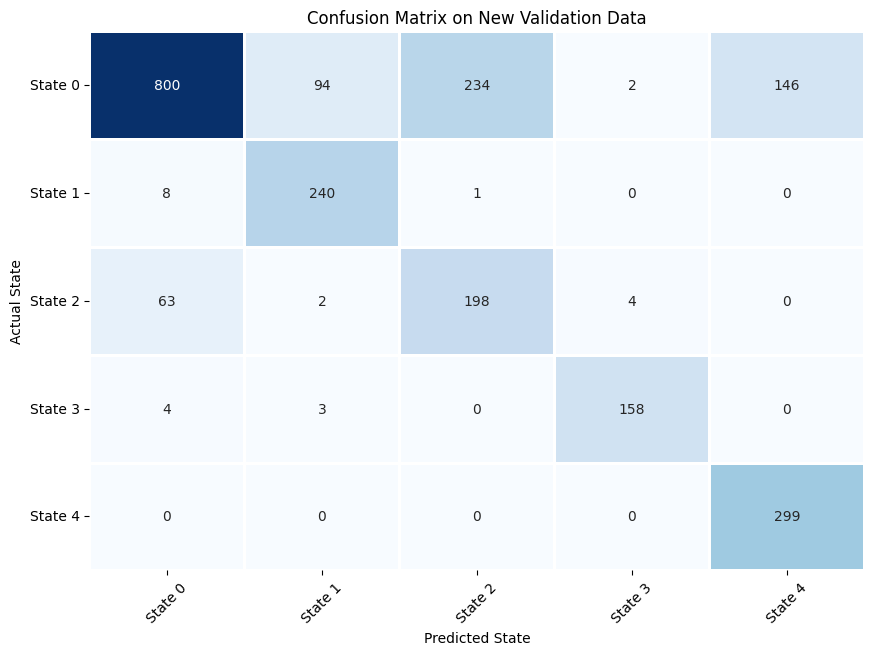

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
conf_matrix = confusion_matrix(new_validation_df['Commanded State'], new_validation_df['Predicted State'])

# Visualize the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g', cbar=False, linewidths=1)


plt.xlabel('Predicted State')
plt.ylabel('Actual State')
plt.title('Confusion Matrix on New Validation Data')
plt.xticks(ticks=np.arange(5) + 0.5, labels=['State 0', 'State 1', 'State 2', 'State 3', 'State 4'], rotation=45)
plt.yticks(ticks=np.arange(5) + 0.5, labels=['State 0', 'State 1', 'State 2', 'State 3', 'State 4'], rotation=0)
plt.show()

In [19]:
from sklearn.model_selection import train_test_split

features = validation_df[['EAR Avg', 'MAR', 'Head Rot X', 'Head Rot Y', 'Blink Rate']]
labels = validation_df['Commanded State']
#X_train, X_test, y_train, y_test = train_test_split(features, labels, stratify=labels, test_size=0.2)
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.3, stratify=labels, random_state=42)


In [20]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=None)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [21]:
from sklearn.metrics import accuracy_score

y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Data:", accuracy)


Accuracy on Test Data: 1.0


In [22]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)


Confusion Matrix:
 [[ 90   0   0   0   0]
 [  0  79   0   0   0]
 [  0   0 101   0   0]
 [  0   0   0  75   0]
 [  0   0   0   0  75]]


In [23]:
from sklearn.metrics import classification_report

class_report = classification_report(y_test, y_pred)
print("Classification Report:\n", class_report)

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        90
           1       1.00      1.00      1.00        79
           2       1.00      1.00      1.00       101
           3       1.00      1.00      1.00        75
           4       1.00      1.00      1.00        75

    accuracy                           1.00       420
   macro avg       1.00      1.00      1.00       420
weighted avg       1.00      1.00      1.00       420



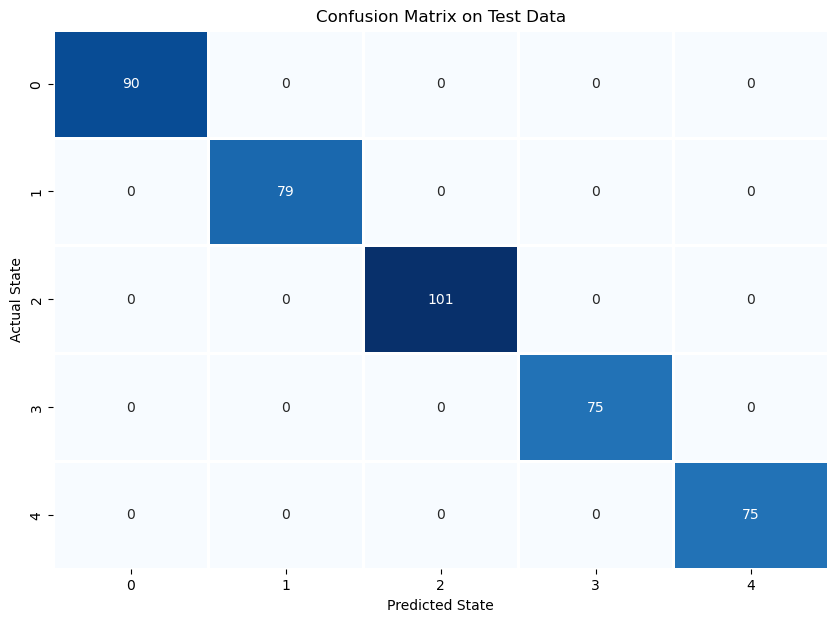

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g', cbar=False, linewidths=1)
plt.xlabel('Predicted State')
plt.ylabel('Actual State')
plt.title('Confusion Matrix on Test Data')
plt.show()


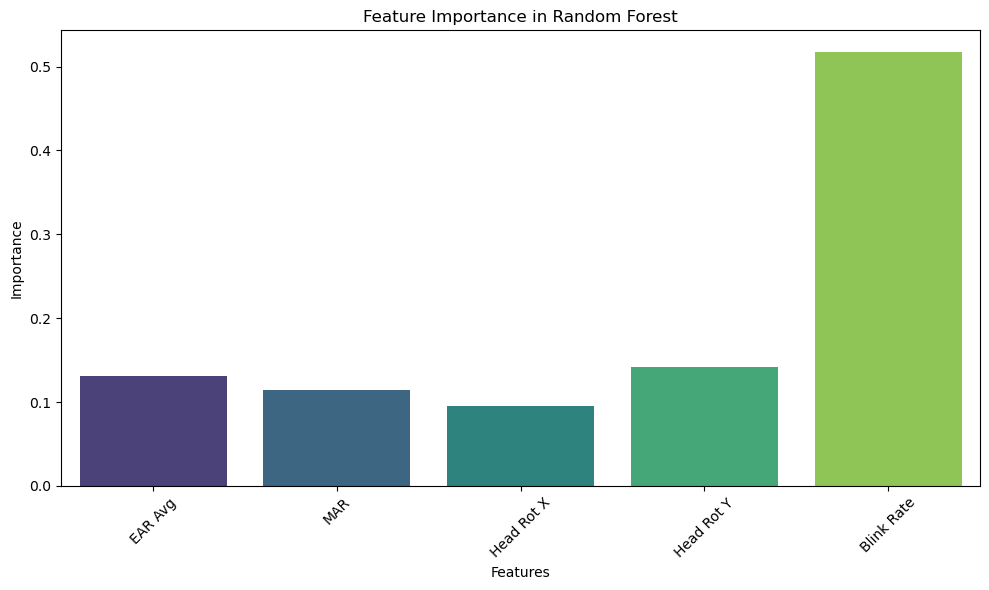

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get the feature names from the training data
features = X_train.columns
importances = rf_model.feature_importances_

# Create a DataFrame for plot
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Feature', y='Importance', palette='viridis')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance in Random Forest')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Confusion Matrix (Random Forest):
 [[809   0   2 465   0]
 [  8 241   0   0   0]
 [ 49   0 218   0   0]
 [ 23   0  39 103   0]
 [  0   0   0   0 299]]
Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.91      0.63      0.75      1276
           1       1.00      0.97      0.98       249
           2       0.84      0.82      0.83       267
           3       0.18      0.62      0.28       165
           4       1.00      1.00      1.00       299

    accuracy                           0.74      2256
   macro avg       0.79      0.81      0.77      2256
weighted avg       0.87      0.74      0.78      2256

Accuracy (Random Forest): 0.7402482269503546


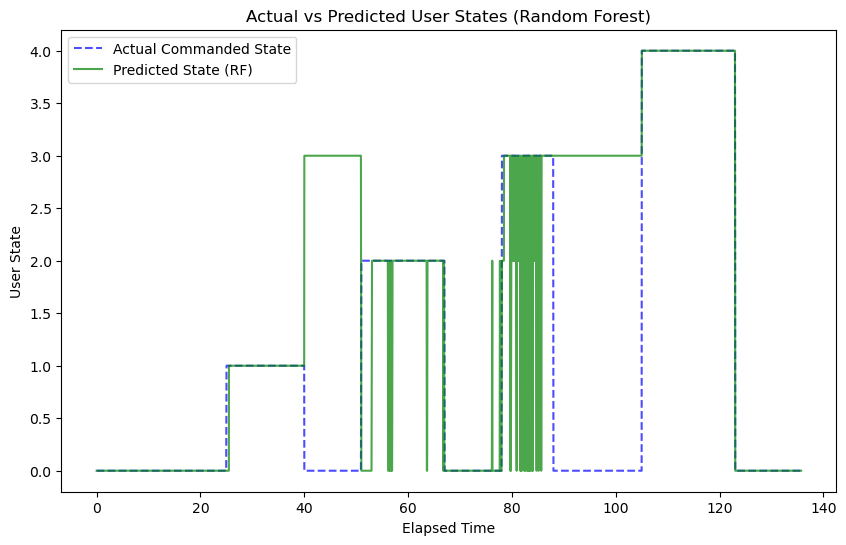

In [26]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt

# Use the same features used during training
features_all = new_validation_df[['EAR Avg', 'MAR', 'Head Rot X', 'Head Rot Y', 'Blink Rate']]
labels_all = new_validation_df['Commanded State']

# Predict using the trained Random Forest
predictions_rf = rf_model.predict(features_all)

# Store predictions in the df
new_validation_df['Predicted State RF'] = predictions_rf

# Evaluate predictions
conf_matrix_rf = confusion_matrix(labels_all, predictions_rf)
print("Confusion Matrix (Random Forest):\n", conf_matrix_rf)

class_report_rf = classification_report(labels_all, predictions_rf)
print("Classification Report (Random Forest):\n", class_report_rf)

accuracy_rf = accuracy_score(labels_all, predictions_rf)
print("Accuracy (Random Forest):", accuracy_rf)

# Step 5: Plot Actual vs Predicted over Time
plt.figure(figsize=(10, 6))
plt.plot(new_validation_df['Elapsed Time'], new_validation_df['Commanded State'], label='Actual Commanded State', color='blue', linestyle='--', alpha=0.7)
plt.plot(new_validation_df['Elapsed Time'], new_validation_df['Predicted State RF'], label='Predicted State (RF)', color='green', linestyle='-', alpha=0.7)
plt.xlabel('Elapsed Time')
plt.ylabel('User State')
plt.title('Actual vs Predicted User States (Random Forest)')
plt.legend()
plt.show()